## ASISTENTE DE CANASTA FAMILIAR

Proyecto Final<br>
Elaborado Por: Luis Manuel Morales<br>
Curso: Python for Data Analysis<br>
Corte: Diploma Ciencia de Datos e IA Aplicada_827648_DIL.DATO_2026-1A<br>
Instituto: UCU / URUGUAY

## 1. DEFINICIÓN DEL PROBLEMA

Se cuenta con un conjunto de datos vinculados a los precios de los productos que se distribuyen en Uruguay, informados SIPC (Sistema de Información de Precios al Consumidor). Se desea preparar los datos para entrenar un modelo de machine learning que pueda asistir en la compra de productos y/o canasta familiar, contemplando los siguientes atributos:
- Tipo de producto
- Época del año
- Cadena

Se espera que el modelo pueda responder a los siguientes planteamientos:
- Productos y costo de la canasta familiar
- Cadenas que ofrecen un mejor costo de la canasta familiar
- Sugerencia de productos por rango de precios


## 2. RECOPILACIÓN DE DATOS

> Dataset de [precios.uy](https://www.precios.uy/category/reporte-mensual/)

Observamos información del dataset (Precios)

| Variable  |                    Definition                    |  type   |
|:---------:|:------------------------------------------------:|:-------:|
|  Periodo  |               Preiodo (Mes y Año)                | String  |
|   Grupo   |           Grupo o famila del producto            | String  |
| Producto  |           Nombre genérico del producto           | String  |
|   Super   |        Nombre Fantasía o Establecimiento         | String  |
|  Precio   |                      Precio                      | Decimal |

> Importamos las librerías necesarias para el proyecto

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyarrow.lib import nulls
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest
# extensiones
import hashlib
import locale
import datetime as dt

from streamlit import cache
from sympy import uppergamma
from sympy.sets.fancysets import Naturals


> Cargamos el Data Frame

In [2]:
# carga de datos al dataframe
df = pd.read_csv("../data/raw/p4ds_cadenas_unificadas_2025.csv")

## Paso 3: Análisis Descriptivo

Conocer las dimensiones y tipologías de datos del objeto con el que estamos trabajando es vital. Para ello necesitamos el atributo `shape` para obtener las dimensiones del objeto y la función `info()` para conocer la tipología y la cantidad de valores no nulos. Otros muy utilizados son el atributo `dtypes`, las funciones `nunique()`, `describe()`, entre otras

In [3]:
# Obtener las dimensiones
df.shape

(26834, 5)

In [4]:
# Obtener información sobre tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26834 entries, 0 to 26833
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Periodo   26834 non-null  str  
 1   Grupo     26671 non-null  str  
 2   Producto  26812 non-null  str  
 3   Super     24237 non-null  str  
 4   Precio    26401 non-null  str  
dtypes: str(5)
memory usage: 3.0 MB


In [5]:
df.describe().T

,count,unique,top,freq
Periodo,26834,12,Dic25,2333
Grupo,26671,10,Alimentos y bebidas,13261
Producto,26812,427,"Jabón de tocador Dove Blanco, 90 grs.",209
Super,24237,17,Red Expres,2260
Precio,26401,2234,"75,00",334


> ### Observaciones:
>
> Luego de haber hecho la carga de los datos tenemos los siguientes detalles:
>
> - Existen un total de 26384 filas, en este caso, cada fila representa variaciones de precios de los productos informados por un establecimiento por un período dado. <br>
> - Identificacmos 5 columnas a continuación se describen: <br>
>> - `Periodo`: variable refiere al periodo de recolección del dato en formato <mm><yy>.
>> - `Grupo`: variable que refiere el grupo o familia de alimentos de los productos.
>> - `Producto`: Identificador del producto, representado por un texto con la siguiente estrucutura  nombre_producto + marca + presentación.
>> - `Super`: Nombre de fantasía o del establecimiento comercial.
>> - `Perecio`: Precio informado. Viene en formato texto dado que fué exportado en formato numérico español. Es necesario hacer una transformación para poder trabajar con el dato.
> - Totos los datos fueron captados cómo textos, es necesario realizar conversión numérica a `Precios`

## Paso 4: Limpieza de Datos

### 4.1 Limpieza de datos: Eliminar duplicados

Un punto muy importante a tener en cuenta en este paso es eliminar aquellas instancias que pudieran estar duplicadas en el conjunto de datos.

In [6]:
# listamos las filas duplicadas
df[df.duplicated(keep=False)]

,Periodo,Grupo,Producto,Super,Precio
34,Abr25,Alimentos y bebidas,Aceite de girasol Óptimo Envase 900 cc,Ta - Ta,"99,00"
44,Abr25,Alimentos y bebidas,Aceite de maíz Delicia Envase 900 cc,Red Market,"105,00"
54,Abr25,Alimentos y bebidas,Aceite de maíz Río de la Plata Envase 900 cc,Red Market,"139,50"
119,Abr25,Alimentos y bebidas,"Agua de mesa sin gas Matutina 2,5 lts",Red Market,"59,00"
133,Abr25,Alimentos y bebidas,"Agua de mesa sin gas Salus 2,25 lts",Tienda Inglesa,"79,00"
...,...,...,...,...,...
25684,Mar25,Alimentos y bebidas,Fideos secos al huevo Adria Paquete 500 grs.,NaN,"92,00"
25705,Oct25,Cuidado personal,"Repelente aerosol Off! Family Aerosol, 170cm3",NaN,"362,00"
25734,Abr25,Alimentos y bebidas,Pulpa de tomate Conaprole Envase 1 lt.,NaN,"94,00"
25740,Abr25,Cuidado personal,Jabón de tocador Astral plata Unidad 125 grs.,NaN,"49,00"


In [7]:
# contamos la cantidad de duplicados
df.duplicated().sum()

np.int64(1625)

#### RESULTADO:

Se encontraron 1625 duplicados. Se pudo validar que los duplicados corresponden a filas con dos o más ocureencias. Al eliminar los duplicados tenemos 25209 filas.

In [8]:
# eliminamos los duplicados
df = df.drop_duplicates()

# hacemos un respaldo sin los duplicados
df_unique = df.copy(deep=True)

In [9]:
# consultamos la información del dataframe y verificamos que ya no están los duplicados
df.info()

<class 'pandas.DataFrame'>
Index: 25209 entries, 0 to 26833
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Periodo   25209 non-null  str  
 1   Grupo     25050 non-null  str  
 2   Producto  25187 non-null  str  
 3   Super     22722 non-null  str  
 4   Precio    24776 non-null  str  
dtypes: str(5)
memory usage: 3.0 MB


In [10]:
# pedimos mostrar las filas duplicadas
df[df.duplicated(keep=False)]


,Periodo,Grupo,Producto,Super,Precio


> #### Resultado
> - Se lograron elimanr exitosamente los duplicados

### 4.2 Limpieza de datos: Ajustar los tipos de valores

> - Al momento de generar el dataframe, observamos que la columna `Precio` quedo como tipo de dato texto. A los efectos es necesario convertir los valores de esta columan a un valor decimal.
> - Adicionalmente a nivel de las columnas de tipo texto, observamos la presencia de caracteres inválidos, asi que se hizo un filtro para eliminarlos.
> - La columna `Periodo` vamosa convertila en formato de tipo fecha para darle valor al dato y poder tener mejores herramientas para el análisis.

In [15]:
# Restaurar dataframe sin repetidos (descomentar solo para restaurar el paso)
# df = df_unique.copy(deep=True)

In [16]:
# conversión a decimal de Precio
df['Precio'] = df['Precio'].str.replace(',', '.', regex=False)
df['Precio'] = pd.to_numeric(df['Precio'], errors='coerce')

# Eliminar caracteres inválidos y limitar a un espaciado entre palabras
df['Grupo'] =  df['Grupo'].str.replace(r'\s+', ' ', regex=True)
df['Producto'] = df['Producto'].str.replace(r'\s+', ' ', regex=True)
df['Super'] = df['Super'].str.replace(r'\s+', ' ', regex=True)

In [24]:
df

,Periodo,Grupo,Producto,Super,Precio
0,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto,80.0
1,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto Express,99.0
2,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Disco,99.0
3,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Ta - Ta,95.0
4,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Tienda Inglesa,97.0
...,...,...,...,...,...
26829,Dic25,Cuidado personal,"Afeitadora Xtreme3 Piel Delicada X1, 1 unidad",Devoto Express,1010.0
26830,Mar25,Cuidado personal,"Perfume Delice Candy, 50 ml.",Farmashop,6210.0
26831,Feb25,Cuidado personal,"Toallitas Femeninas Ladysoft Basica, 16 us.",Tienda Inglesa,1780.0
26832,Dic25,Frutas y verduras,"Papa Blanca, 1 kg.",Disco,1090.0


In [45]:
# Ajustes para la fecha (%b%y) (es_SP)
try:
    # mes: Ene -> Jan
    df['Periodo'] = df['Periodo'].str.replace('Ene', 'Jan', regex=False)
    # mes: Abr -> Apr
    df['Periodo'] = df['Periodo'].str.replace('Abr', 'Apr', regex=False)
    # mes: Ago -> Aug
    df['Periodo'] = df['Periodo'].str.replace('Ago', 'Aug', regex=False)
    # mes: Dic -> Dec
    df['Periodo'] = df['Periodo'].str.replace('Dic', 'Dec', regex=False)
    # convertir a columna a fecha
    df['Periodo'] = pd.to_datetime(df['Periodo'], format="%b%y", errors="raise")
except ValueError as e:
    print(f"Caught a ValueError: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
finally:
    print(df['Periodo'])

0       2025-04-01
1       2025-04-01
2       2025-04-01
3       2025-04-01
4       2025-04-01
           ...    
26829   2025-12-01
26830   2025-03-01
26831   2025-02-01
26832   2025-12-01
26833   2025-04-01
Name: Periodo, Length: 25209, dtype: datetime64[us]


In [46]:
# Verificamos que la conversion haya sido exitosa
df

,Periodo,Grupo,Producto,Super,Precio
0,2025-04-01,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto,80.0
1,2025-04-01,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto Express,99.0
2,2025-04-01,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Disco,99.0
3,2025-04-01,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Ta - Ta,95.0
4,2025-04-01,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Tienda Inglesa,97.0
...,...,...,...,...,...
26829,2025-12-01,Cuidado personal,"Afeitadora Xtreme3 Piel Delicada X1, 1 unidad",Devoto Express,1010.0
26830,2025-03-01,Cuidado personal,"Perfume Delice Candy, 50 ml.",Farmashop,6210.0
26831,2025-02-01,Cuidado personal,"Toallitas Femeninas Ladysoft Basica, 16 us.",Tienda Inglesa,1780.0
26832,2025-12-01,Frutas y verduras,"Papa Blanca, 1 kg.",Disco,1090.0


### A continuación vamos va validar como queda la estructura del dataframe:
>- Tenemos un total de 25209 filas únicas
>- 5 Columnas de datos, de las cuales 4 son de tipo texto y una de tipo decimal.

In [47]:
df.shape

(25209, 5)

In [48]:
df.info()

<class 'pandas.DataFrame'>
Index: 25209 entries, 0 to 26833
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Periodo   25209 non-null  datetime64[us]
 1   Grupo     25050 non-null  str           
 2   Producto  25187 non-null  str           
 3   Super     22722 non-null  str           
 4   Precio    24305 non-null  float64       
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 2.8 MB


In [52]:
# creamos respaldo del dataframe
df_unico_tipo_dato_ok = df.copy(deep=True)


In [50]:
# verificamos el cambio en el tipo de dato de Periodo
df.describe(include='all')

,Periodo,Grupo,Producto,Super,Precio
count,25209,25050,25187,22722,24305.000000
unique,NaN,10,427,17,NaN
top,NaN,Alimentos y bebidas,"Jabón de tocador Dove Blanco, 90 grs.",Red Expres,NaN
freq,NaN,12459,195,2110,NaN
mean,2025-06-16 10:18:07.325955,NaN,NaN,NaN,241.707553
min,2025-01-01 00:00:00,NaN,NaN,NaN,6.000000
25%,2025-03-01 00:00:00,NaN,NaN,NaN,75.000000
50%,2025-06-01 00:00:00,NaN,NaN,NaN,129.000000
75%,2025-10-01 00:00:00,NaN,NaN,NaN,249.900000
max,2025-12-01 00:00:00,NaN,NaN,NaN,25800.000000


## Paso 5: Análisis de Variables

#### 5.1) Análisis de Variables Univariante Categóricas

Para representar este tipo de variables utilizaremos histogramas. Antes de comenzar a graficar, debemos identificar cuáles son categóricas, y se puede comprobar fácilmente analizando el rango de valores.

En este caso, las variables categóricas son: `Periodo`, `Grupo`, `Producto`, `Super` y `Precio`:

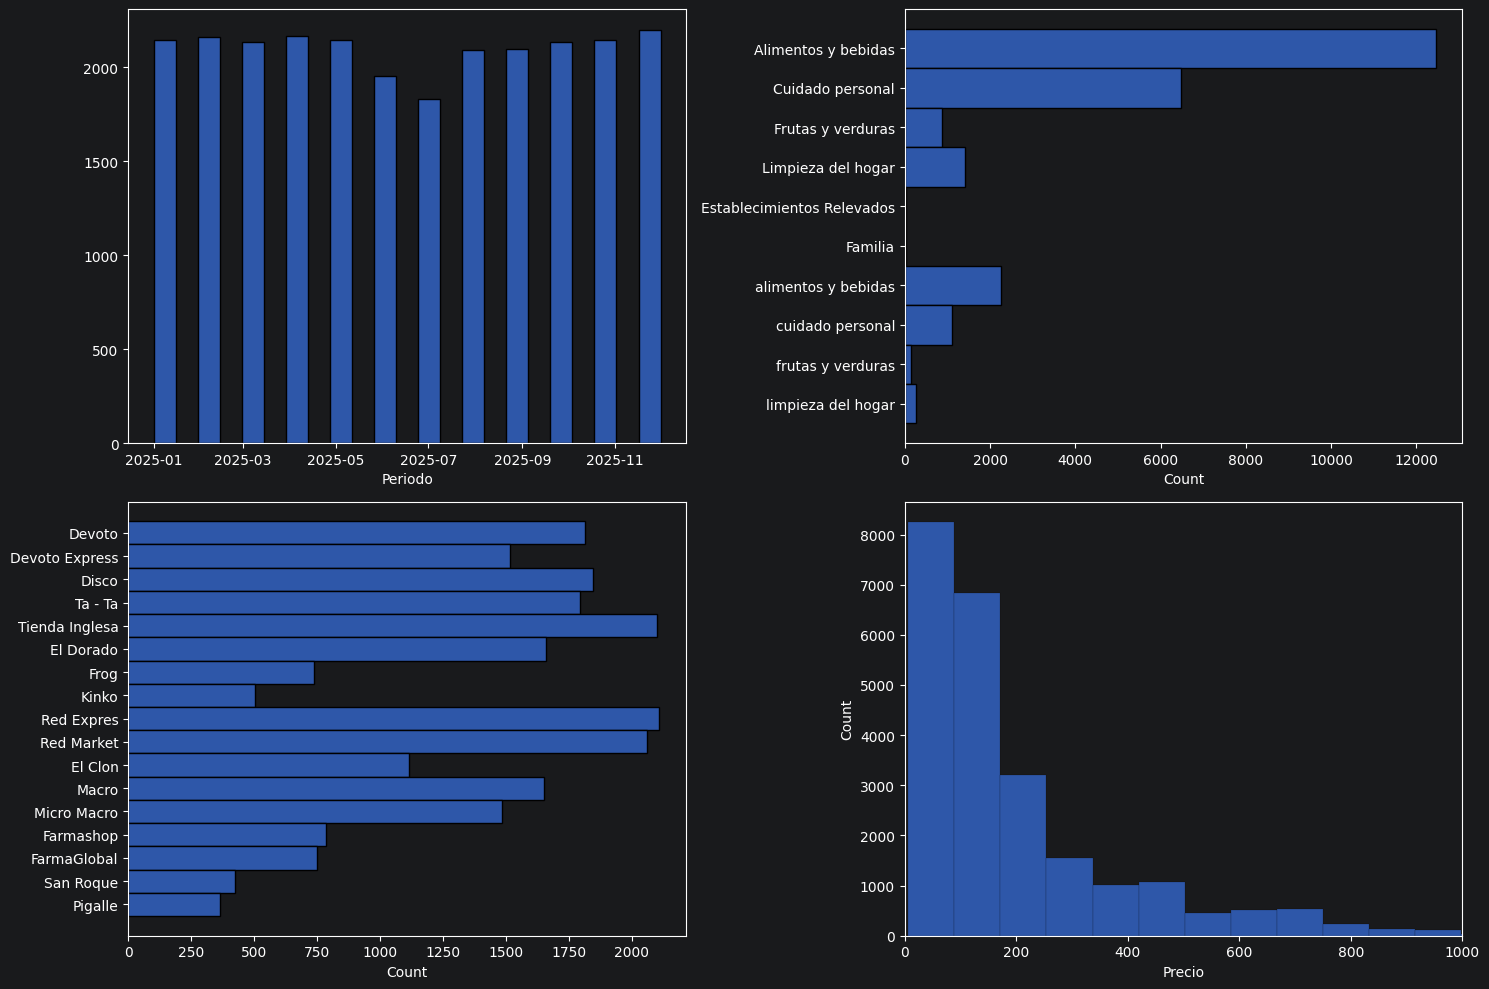

In [65]:
fig, axis = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(ax=axis[0, 0], data=df, x="Periodo").set(ylabel=None)
sns.histplot(ax=axis[0, 1], data=df, y="Grupo").set(ylabel=None)
sns.histplot(ax=axis[1, 0], data=df, y="Super").set(ylabel=None)
sns.histplot(ax=axis[1, 1], data=df, x="Precio").set_xlim(0, 1000)

plt.tight_layout()
plt.show()


>### Observación
> - Se detectó un valor que no aporta datos en Grupo. El valor <b>Establecimientos Relevados</b> no aporta valor al objetivo del presente proyecto. Vamos a listar los datos y posteriormente eliminar las filas vinculadas. Un total de 68 filas serán eliminadas del dataframe.
> - Se detecto duplicidad en Grupo ya que hay valores que respresentan lo mismo, difieren que estan en mayúsculas y minúsculas. Se unificaran usando el formato `Title`.
> - Se observan valores de `Precio` que no estan acordes al valor real. Realizaremos un analisis y depuración de los datos que estén fuera de un rango coherente para los productos referenciados.

### Depuración de datos:
Por valores de `Prodducto` incorrectos:
>- Eliminar las filas de Producto = Establecimiento relevado
>- Eliminar las filas de Producto = Familia

In [153]:
# Visualizar los datos de Grupo con valor igual a Establecimientos Relevados
# df = df_unico_tipo_dato_ok.copy(deep=True)
filtro_valores = ['Establecimientos Relevados', 'Familia']
data_filtrada = df[df['Grupo'].isin(filtro_valores)]

# mostrar los datos a eliminar
data_filtrada
#


,Periodo,Grupo,Producto,Super,Precio


In [154]:
# Eliminar los datos de Grupo con valor igual a Establecimientos Relevados
filtro_valores = ['Establecimientos Relevados', 'Familia']
df = df[~df['Grupo'].isin(filtro_valores)]

# Borramos las referencias a los indices
df = df.drop(df[df['Producto'] == 'Establecimientos Relevados'].index)
df = df.drop(df[df['Producto'] == 'Familia'].index)


In [155]:
# Verificando los datos fueron eliminados permanentemente
data_filtrada = df.query('Producto == "Establecimientos Relevados" | Producto == "Familia"')
data_filtrada

,Periodo,Grupo,Producto,Super,Precio


In [71]:
# Unificar el formato de los valores para Grupo
df['Grupo'] = df['Grupo'].str.title()

In [157]:
# Realizamos un respaldo de dataframe
# df_unico_tipo_dato_ok.csv
# - no tiene datos duplicados
# - Se eliminaron las filas de productos = Establecimientos Relevados
# - Se eliminaron las filas de productos = Familia

# respaldo en archivo csv
df.to_csv('../data/processed/df_unico_productos_depurados.csv', index=False)

# respaldo en memoria
df_unico_tipo_dato_ok = df.copy(deep=True)

### Depuración de datos:
Por valores de `Precio` incorrectos:
>- Eliminar las filas con `Precios` > 900 con `Grupo` = Alimentos Y Bebidas
>- Eliminar las filas con `Precios` > 1500


In [159]:
# Listado de los datos con precios fuera de rango
# data_filtrada = df[(df['Precio'] > 900) & (df['Grupo'] == 'Alimentos Y Bebidas')]
data_filtrada = df.query('Precio > 900 & Producto == "Alimentos Y Bebidas"')
data_filtrada

,Periodo,Grupo,Producto,Super,Precio


In [160]:
# Eliminar de los datos con precios fuera de rango
df = df[~((df['Precio'] > 900) & (df['Grupo'] == 'Alimentos Y Bebidas'))]
# Borramos las referencias a los indices
df = df.drop(df[df['Producto'] == 'Alimentos Y Bebidas'].index)

In [162]:
# Listado de los datos con precios fuera de rango
#data_filtrada = df[(df['Precio'] > 1500)]
data_filtrada = df.query('Precio > 1500')
data_filtrada

,Periodo,Grupo,Producto,Super,Precio


In [163]:
# Listado de los datos con precios fuera de rango
df = df[~(df['Precio'] > 1500)]
# Borramos las referencias a los indices
df = df.drop(df[df['Precio'] > 1500].index)

### Regeneramos los histogramas
Constatamos que los histogramas sean correctos y que no hayan valores fuera de rango.


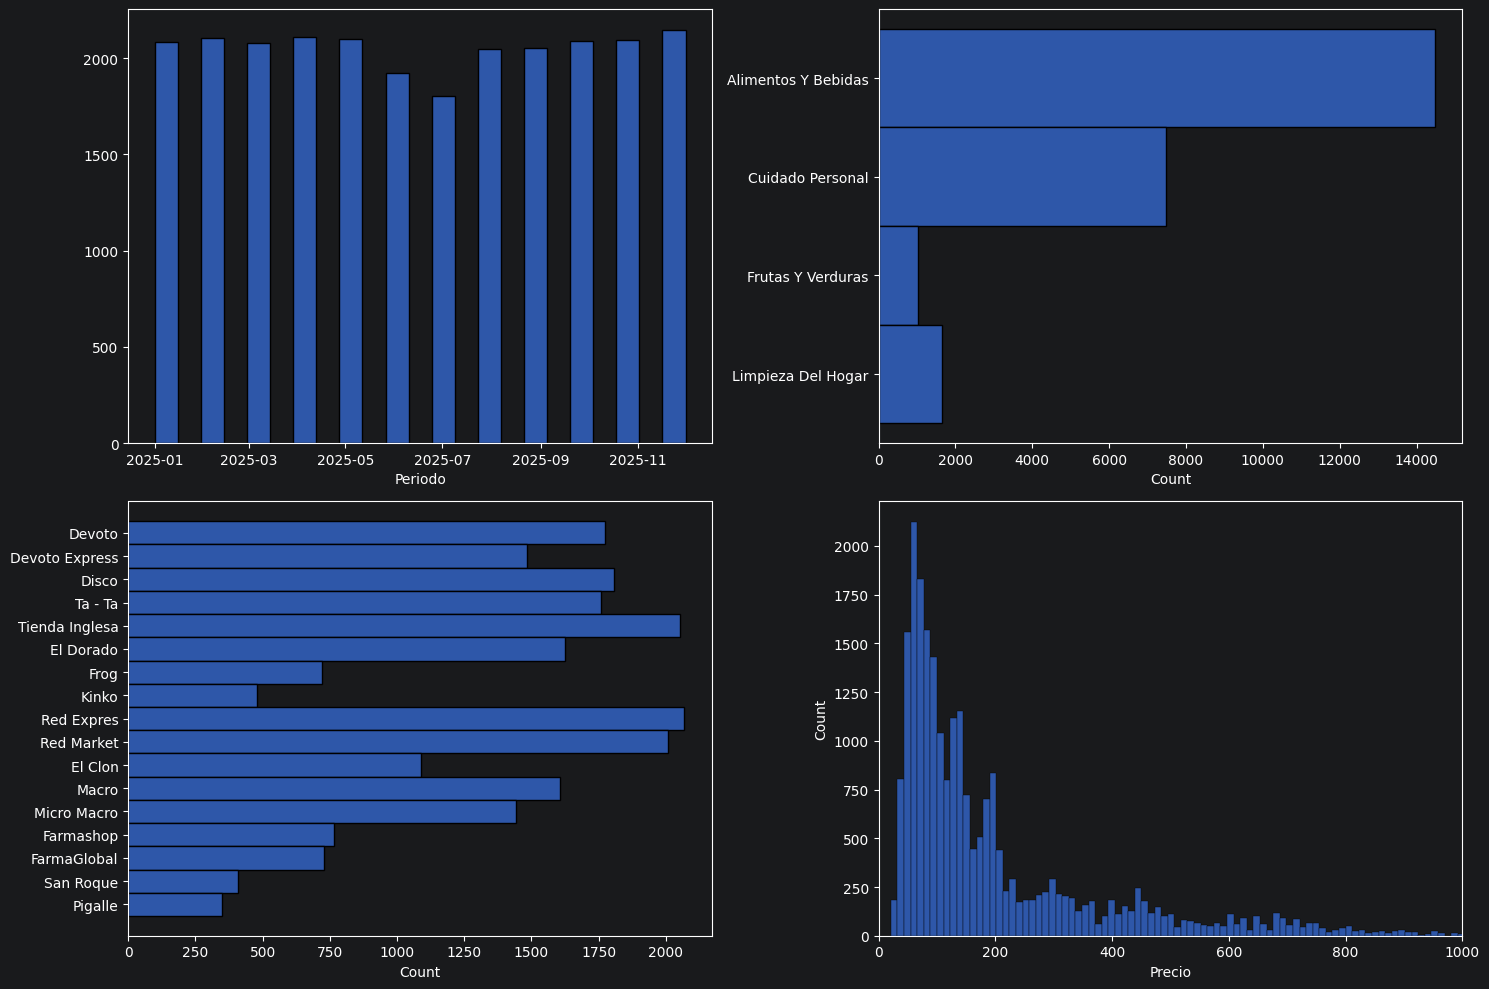

In [164]:
# Regeneramos los histogramas con los valores corregidos
fig, axis = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(ax=axis[0, 0], data=df, x="Periodo").set(ylabel=None)
sns.histplot(ax=axis[0, 1], data=df, y="Grupo").set(ylabel=None)
sns.histplot(ax=axis[1, 0], data=df, y="Super").set(ylabel=None)
sns.histplot(ax=axis[1, 1], data=df, x="Precio").set_xlim(0, 1000)

plt.tight_layout()
plt.show()


In [165]:
# Realizamos un respaldo de dataframe
# df_unico_productos_precios_depurados.csv
# - no tiene datos duplicados
# - Se eliminaron las filas de productos = Establecimientos Relevados
# - Se eliminaron las filas de productos = Familia
# - Se eliminaron las filas de precios > 900 en Grupo = Alimentos y Bebidas
# - Se eliminaron las filas de precios > 1500

# respaldo en archivo csv
df.to_csv('../data/processed/df_unico_productos_precios_depurados.csv', index=False)

# respaldo en memoria
df_unico_tipo_dato_ok = df.copy(deep=True)

### Depuración de datos:
Un detalle que limita el analisis de los datos tiene ver que la `Producto` es un texto que guarda datos de los productos, entre los cuales podemos mencionar:
>- Nombre del producto
>- Marca
>- Presentación

Para extraer estos valores, se elaboró un script en Python que permite procesar los datos de la columna `Producto` y extraer los atributos de los productos.

El script esta en la carpeta utils y se llama `extraer_producto_marca_presentacion.py`

Este script genera un archivo cvs de productos con los atributos de los productos y se adicionó columnas que permiten definir la canasta familiar, en base a la familia de productos y cantidad del producto..




In [2]:
# A continuación vamos a crear un dataframe unificado con los datos depurados y los atributos de los productos extraídos.

try:
    # Cargamos el dataframe del histórico de precios
    df_precios = pd.read_csv("../data/processed/df_unico_productos_precios_depurados.csv")

    # Cargamos el dataframe del mapa de precios
    df_productos = pd.read_csv("../data/processed/mapa_productos_extraidos_canasta.csv", sep=";", encoding="iso-8859-1")
except ValueError as e:
    print(f"Caught a ValueError: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
#finally:
    #print(df_productos)

In [3]:
# Creando un nuevo dataframe con df_productos + df_precios

df = df_precios.merge(df_productos[['Producto', 'tipo_producto', 'marca', 'presentacion', 'tipo_envoltorio','presentacion_valor', 'presentacion_unidad', 'nombre_comercial', 'canasta_producto', 'canasta_cantidad']], on='Producto', how='left')

df

,Periodo,Grupo,Producto,Super,Precio,tipo_producto,marca,presentacion,tipo_envoltorio,presentacion_valor,presentacion_unidad,nombre_comercial,canasta_producto,canasta_cantidad
0,2025-04-01,Alimentos Y Bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto,80.0,Aceite,Marca Propia,Envase 900 cc,Envase,900.0,CC,Aceite de girasol,1.0,2.0
1,2025-04-01,Alimentos Y Bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto Express,99.0,Aceite,Marca Propia,Envase 900 cc,Envase,900.0,CC,Aceite de girasol,1.0,2.0
2,2025-04-01,Alimentos Y Bebidas,Aceite de girasol Marca Propia Envase 900 cc,Disco,99.0,Aceite,Marca Propia,Envase 900 cc,Envase,900.0,CC,Aceite de girasol,1.0,2.0
3,2025-04-01,Alimentos Y Bebidas,Aceite de girasol Marca Propia Envase 900 cc,Ta - Ta,95.0,Aceite,Marca Propia,Envase 900 cc,Envase,900.0,CC,Aceite de girasol,1.0,2.0
4,2025-04-01,Alimentos Y Bebidas,Aceite de girasol Marca Propia Envase 900 cc,Tienda Inglesa,97.0,Aceite,Marca Propia,Envase 900 cc,Envase,900.0,CC,Aceite de girasol,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24628,2025-10-01,Frutas Y Verduras,"Manzana Red Deliciosa, 1 kg.",Macro,1469.0,Manzana,Genérico,1 kg.,Para Empaquetar,1.0,KG,Manzana Red Deliciosa,NaN,NaN
24629,2025-03-01,Alimentos Y Bebidas,Sal fina yodada fluorada Sek Paquete 500 grs.,Disco,640.0,Sal,Sek,Empaque 500 grs.,Empaque,500.0,GR,Sal fina yodada fluorada,NaN,NaN
24630,2025-02-01,Cuidado Personal,Curitas Ready Plast 8 us.,Frog,500.0,Curitas,Ready Plast,Empaque 8 Unidades,Empaque,8.0,UNIDADES,Curitas,NaN,NaN
24631,2025-12-01,Cuidado Personal,"Afeitadora Xtreme3 Piel Delicada X1, 1 unidad",Devoto Express,1010.0,Afeitadora,Xtreme3,Empaque 1 Unidad,Empaque,1.0,UNIDADES,Afeitadora Piel Delicada X 1,NaN,NaN


In [5]:
# Realizamos un respaldo de dataframe
# df_unico_productos_precios_depurados.csv + mapa_productos_extraidos_canasta.csv

df.to_csv("../data/processed/df_precios_depurado_enriquecido.csv", index=False, encoding="utf-8-sig", sep=";")

In [6]:
df.groupby(["Grupo", "tipo_producto", "marca", "presentacion", "nombre_comercial"])["Precio"].agg(
    precio_promedio="mean",
    precio_mediano="median",
    precio_minimo="min",
    precio_maximo="max",
    observaciones="count"
).reset_index()

,Grupo,tipo_producto,marca,presentacion,nombre_comercial,precio_promedio,precio_mediano,precio_minimo,precio_maximo,observaciones
0,Alimentos Y Bebidas,Aceite,Condesa,Envase 900 cc,Aceite de soja,92.010000,71.00,63.0,750.00,130
1,Alimentos Y Bebidas,Aceite,Delicia,Envase 900 cc,Aceite de maiz,122.852857,127.00,98.0,149.00,147
2,Alimentos Y Bebidas,Aceite,Devoto,Envase 900 cc,Aceite de girasol,84.000000,79.00,79.0,99.00,4
3,Alimentos Y Bebidas,Aceite,Marca Propia,Envase 900 cc,Aceite de girasol,93.033333,98.00,79.0,103.00,30
4,Alimentos Y Bebidas,Aceite,Marcas Propias,Envase 900 cc,Aceite de girasol,87.250000,82.00,79.0,99.00,16
...,...,...,...,...,...,...,...,...,...,...
322,Limpieza Del Hogar,Jabon para ropa,Nevex,Empaque Unidad 200 grs.,Jabon para ropa en barra,64.876471,60.00,40.0,540.00,119
323,Limpieza Del Hogar,Jabon para ropa,Primor,Empaque Unidad 200 grs.,Jabon para ropa en barra,36.942105,36.00,35.0,44.90,19
324,Limpieza Del Hogar,Jabon para ropa,Primor,Empaque Unidad 300 grs.,Jabon para ropa en barra,41.942157,39.00,30.0,300.00,102
325,Limpieza Del Hogar,Jabon para ropa,Skip,Empaque 800 grs.,Jabon para ropa en polvo,152.881364,152.00,117.0,175.51,110


#### 5.2) Análisis de Variables Univariante Numéricas

Una **variable numérica** es un tipo de variable que puede tomar valores numéricos (enteros, fracciones, decimales, negativos, etc.) en un rango infinito.

A los efectos la variable 'Precios' es la única columna con valores numéricos, Haremos un ejercicio contemplando los valores de los precios según el grupo o familia de producto.

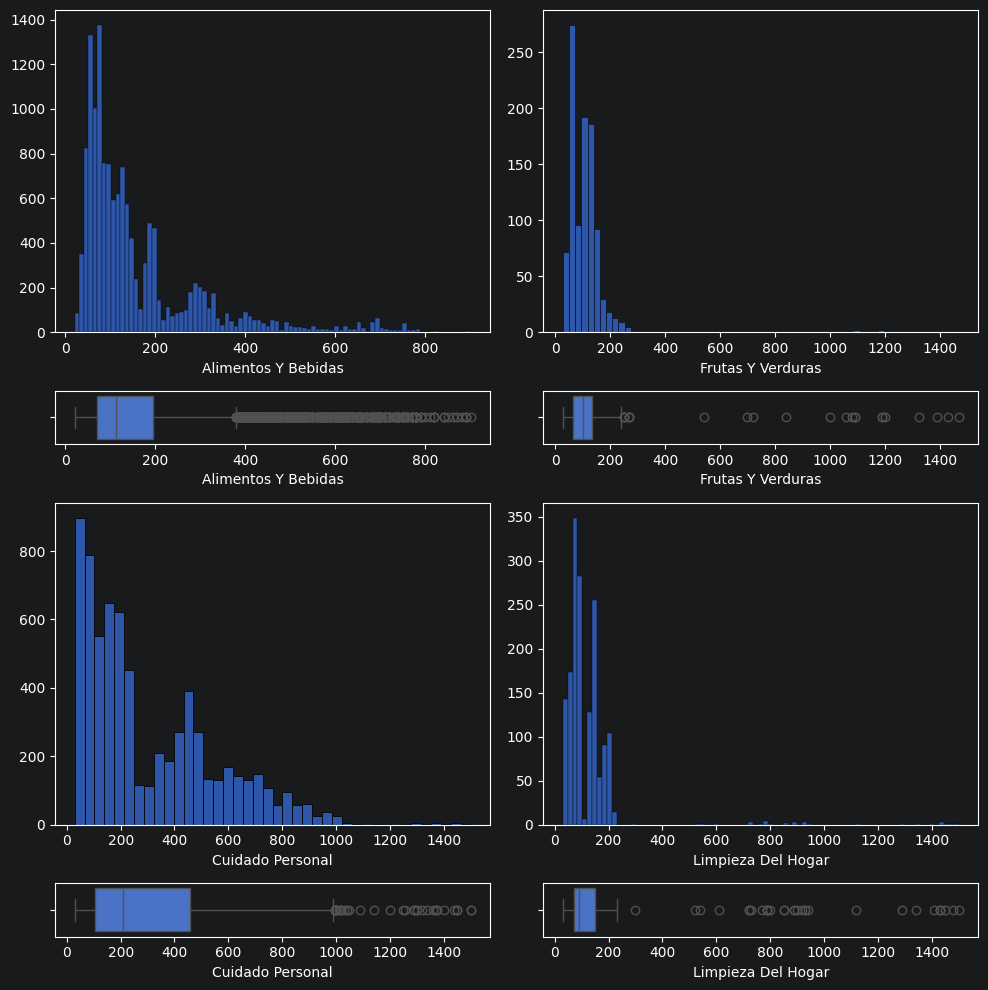

In [196]:
# Generando histogramas de grupos por precios
fig, axis = plt.subplots(4, 2, figsize=(10, 10), gridspec_kw={'height_ratios': [6, 1, 6, 1]})

sns.histplot(ax=axis[0, 0], data=df[(df['Grupo'] == 'Alimentos Y Bebidas')], x="Precio").set(xlabel="Alimentos Y Bebidas", ylabel=None)
sns.boxplot(ax=axis[1, 0], data=df[(df['Grupo'] == 'Alimentos Y Bebidas')], x="Precio").set(xlabel="Alimentos Y Bebidas", ylabel=None)
sns.histplot(ax=axis[0, 1], data=df[(df['Grupo'] == 'Frutas Y Verduras')], x="Precio").set(xlabel="Frutas Y Verduras", ylabel=None)
sns.boxplot(ax=axis[1, 1], data=df[(df['Grupo'] == 'Frutas Y Verduras')], x="Precio").set(xlabel="Frutas Y Verduras", ylabel=None)
sns.histplot(ax=axis[2, 0], data=df[(df['Grupo'] == 'Cuidado Personal')], x="Precio").set(xlabel="Cuidado Personal", ylabel=None)
sns.boxplot(ax=axis[3, 0], data=df[(df['Grupo'] == 'Cuidado Personal')], x="Precio").set(xlabel="Cuidado Personal", ylabel=None)
sns.histplot(ax=axis[2, 1], data=df[(df['Grupo'] == 'Limpieza Del Hogar')], x="Precio").set(xlabel="Limpieza Del Hogar", ylabel=None)
sns.boxplot(ax=axis[3, 1], data=df[(df['Grupo'] == 'Limpieza Del Hogar')], x="Precio").set(xlabel="Limpieza Del Hogar", ylabel=None)

plt.tight_layout()
plt.show()


> #### Observaciones:
>
> - De la visualización resultante podemos observar que las colecciones de datos por grupos de producto cuentan con valores atípicos.
> - Las distribuciones tienen asimetría, la primera totalmente sesgada hacia la izquierda, donde la media es inferior a la moda y la otra con menor tendencia.
> - Se puede concluir que agrupar por familias de productos no genera un aporte significativo. En este punto valdria la pena intentar este mismo procedimiento con tipo de producto. Sin embargo para llevar acabo esta opcion debemos hacer un tratamiento sobre la columna `Producto` para geerar las siguientes columnas:
>> - Tipo de Producto
>> - Marca
>> - Presentacion

### 5.3) Análisis de Variables Multivariante

Tras analizar las características una a una, es momento de analizarlas en relación con la predictora y con ellas mismas, para sacar conclusiones más claras acerca de sus relaciones y poder tomar decisiones sobre su procesamiento.

Así, si quisiéramos eliminar una variable debido a una alta cantidad de valores nulos o ciertos outliers, es necesario antes aplicar este proceso para asegurar que la eliminación de ciertos valores no son críticos para la supervivencia de un pasajero.

#### Observaciones:
Teniendo en cuenta la naturaleza de esta técnica, no vemos necesario aplicarla dado que el conjunto de datos tiene la minima cantidad de columnas o variables para modelar un escenario de valores de toma de decisiones para la compra de productos.

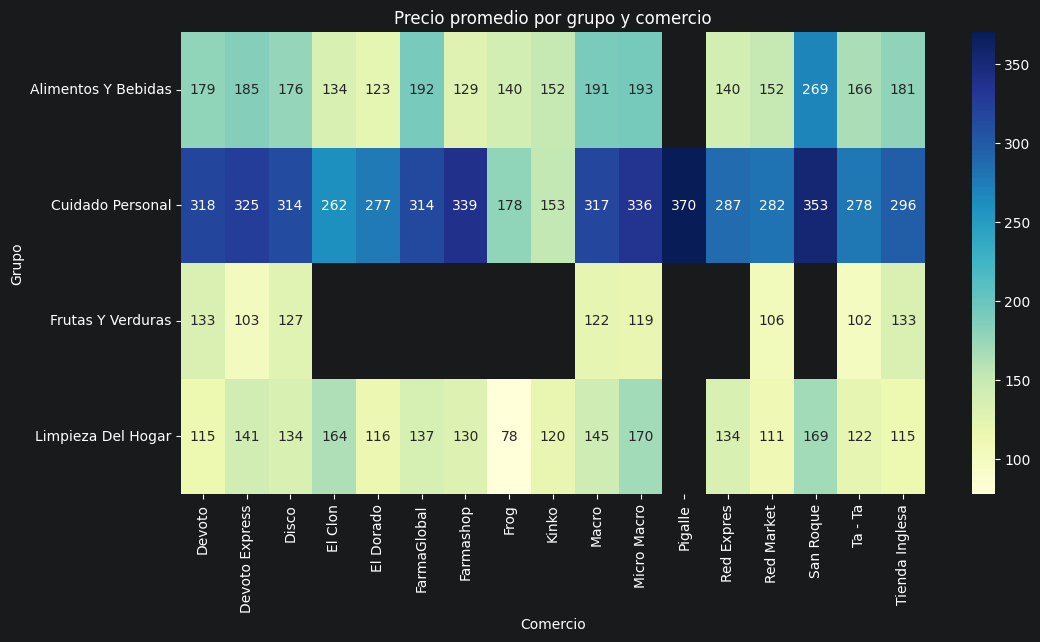

In [202]:
tabla_grupo_comercio = df.pivot_table(
    index="Grupo",
    columns="Super",
    values="Precio",
    aggfunc="mean"
)

plt.figure(figsize=(12, 6))
sns.heatmap(tabla_grupo_comercio, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Precio promedio por grupo y comercio")
plt.xlabel("Comercio")
plt.ylabel("Grupo")
plt.show()

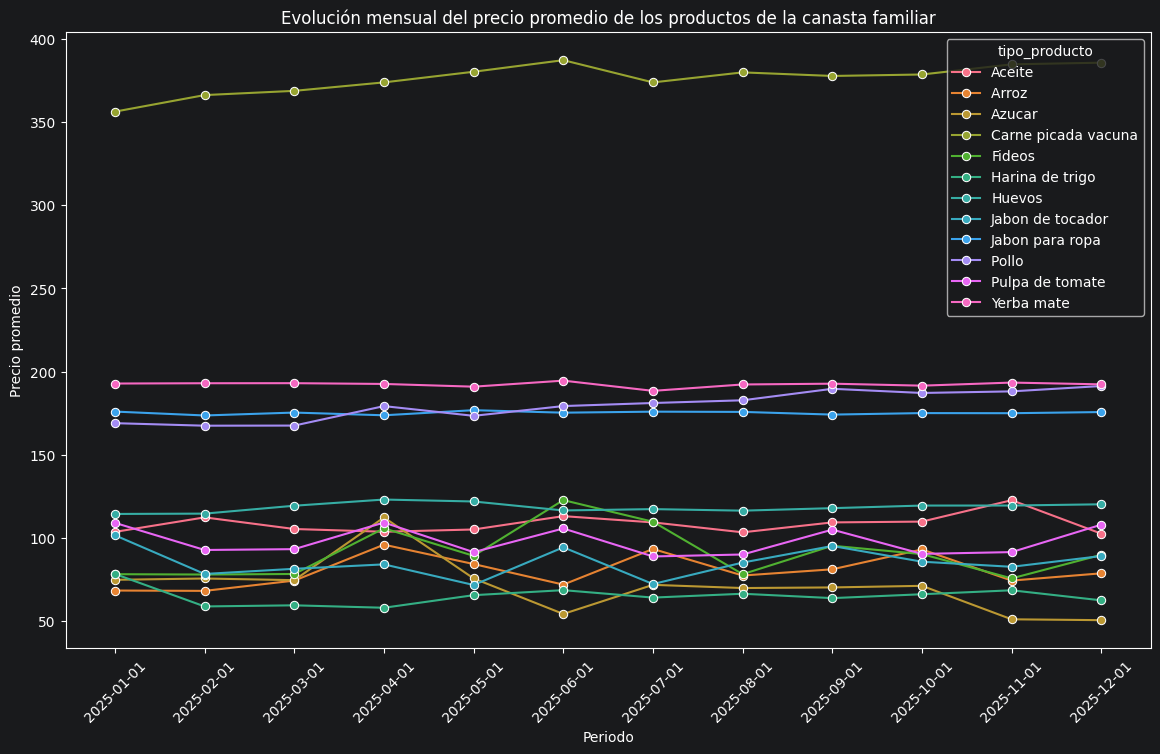

In [229]:
precio_mensual_grupo = (
    df[(df['canasta_producto'] == 1)].groupby(["Periodo", "tipo_producto"])["Precio"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=precio_mensual_grupo,
    x="Periodo",
    y="Precio",
    hue="tipo_producto",
    marker="o"
)

plt.title("Evolución mensual del precio promedio de los productos de la canasta familiar")
plt.xlabel("Periodo")
plt.ylabel("Precio promedio")
plt.xticks(rotation=45)
plt.show()

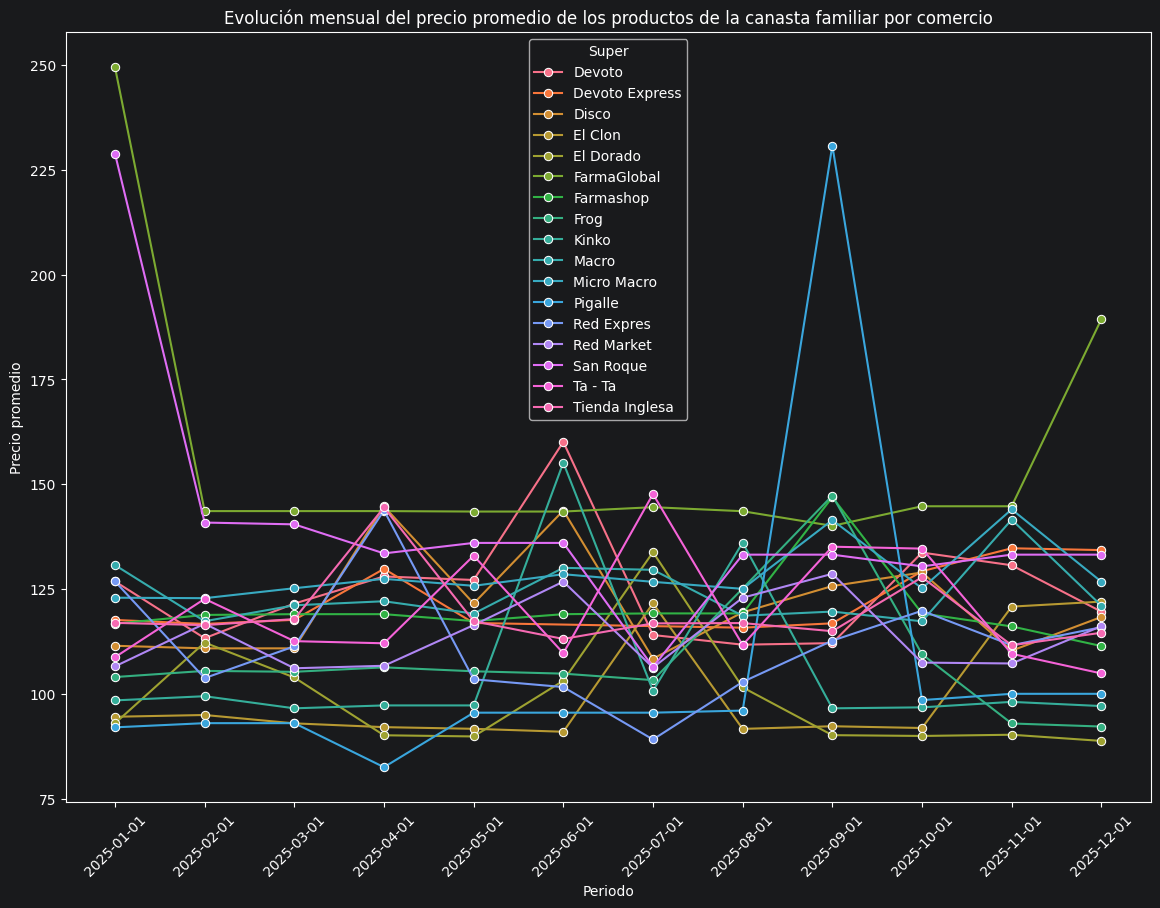

In [230]:
precio_mensual_comercio = (
    df[(df['canasta_producto'] == 1)].groupby(["Periodo", "Super"])["Precio"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 10))
sns.lineplot(
    data=precio_mensual_comercio,
    x="Periodo",
    y="Precio",
    hue="Super",
    marker="o"
)

plt.title("Evolución mensual del precio promedio de los productos de la canasta familiar por comercio")
plt.xlabel("Periodo")
plt.ylabel("Precio promedio")
plt.xticks(rotation=45)
plt.show()

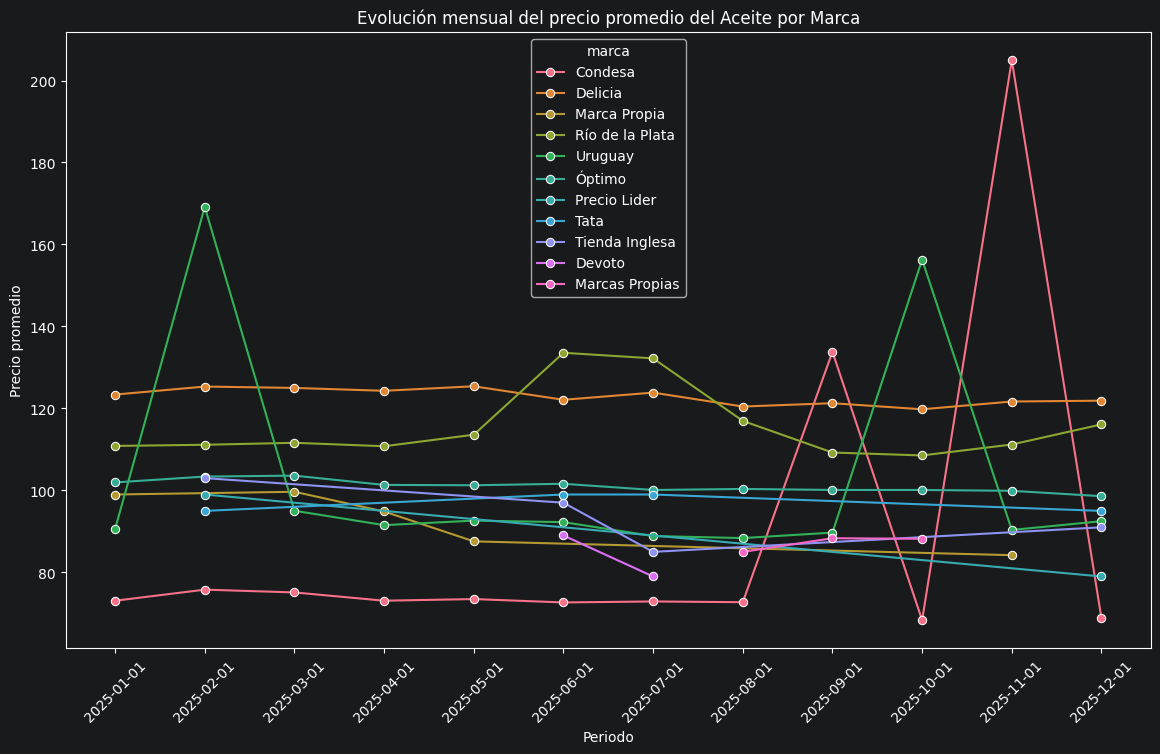

In [221]:
precio_mensual_comercio = (
    df[(df['tipo_producto'] == 'Aceite')].groupby(["Periodo", "marca"])["Precio"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=precio_mensual_comercio,
    x="Periodo",
    y="Precio",
    hue="marca",
    marker="o"
)

plt.title("Evolución mensual del precio promedio del Aceite por Marca")
plt.xlabel("Periodo")
plt.ylabel("Precio promedio")
plt.xticks(rotation=45)
plt.show()

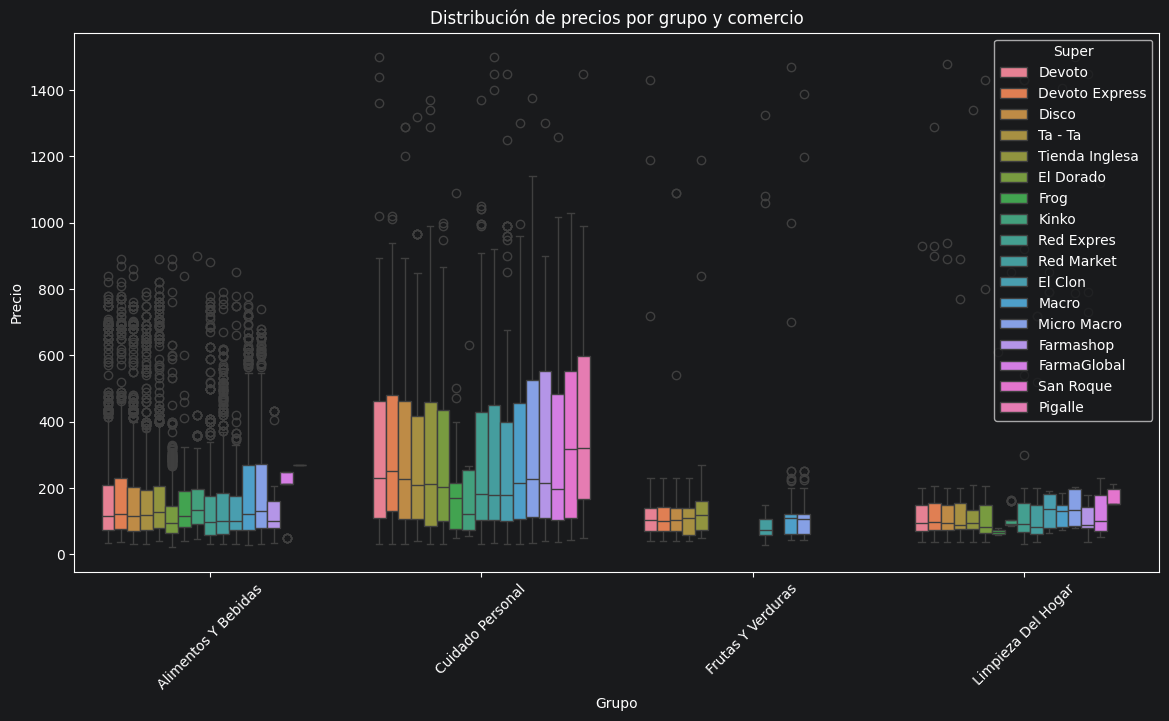

In [214]:
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df,
    x="Grupo",
    y="Precio",
    hue="Super"
)

plt.title("Distribución de precios por grupo y comercio")
plt.xlabel("Grupo")
plt.ylabel("Precio")
plt.xticks(rotation=45)
plt.show()

In [220]:
# Ranking de productos

ranking_productos = df.copy()

ranking_productos["ranking_precio"] = (
    ranking_productos
    .groupby(["Periodo", "Producto"])["Precio"]
    .rank(method="dense", ascending=True)
)

productos_mas_baratos = ranking_productos[
    ranking_productos["ranking_precio"] == 1
].sort_values(["Periodo", "Producto"])

productos_mas_baratos[
    ["Periodo", "Grupo", "Producto", "Super", "Precio"]
]

,Periodo,Grupo,Producto,Super,Precio
5480,2025-01-01,Alimentos Y Bebidas,Aceite de girasol Marca Propia Envase 900 cc,Ta - Ta,95.00
5485,2025-01-01,Alimentos Y Bebidas,Aceite de girasol Río de la Plata Envase 900 cc,El Dorado,109.00
5493,2025-01-01,Alimentos Y Bebidas,Aceite de girasol Uruguay Envase 900 cc,El Dorado,79.00
5504,2025-01-01,Alimentos Y Bebidas,Aceite de girasol Óptimo Envase 900 cc,El Dorado,97.00
5516,2025-01-01,Alimentos Y Bebidas,Aceite de maíz Delicia Envase 900 cc,El Clon,105.00
...,...,...,...,...,...
4689,2025-12-01,Alimentos Y Bebidas,Yogur Calcar Sachet 1 lt.,Red Expres,75.00
4697,2025-12-01,Alimentos Y Bebidas,"Yogur Conaprole BIO TOP Sachet1,200 lt.",Macro,86.73
4703,2025-12-01,Alimentos Y Bebidas,Yogur Parmalat Bio Yogur Sachet 1 lt.,El Dorado,89.90
5354,2025-12-01,Frutas Y Verduras,"Zapallo Calabacín, 1 kg.",Red Market,78.00


In [216]:
df.columns.tolist()


['Periodo',
 'Grupo',
 'Producto',
 'Super',
 'Precio',
 'tipo_producto',
 'marca',
 'presentacion',
 'tipo_envoltorio',
 'presentacion_valor',
 'presentacion_unidad',
 'nombre_comercial',
 'canasta_producto',
 'canasta_cantidad']